In [1]:
import numpy as np
import pandas as pd

In [2]:
d30_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_30bins/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
d30_fold0["fold"] = [0 for i in range(len(d30_fold0))]
d30_fold0["dist"] = [30.0 for i in range(len(d30_fold0))]

In [3]:
d30_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_30bins/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
d30_fold1["fold"] = [1 for i in range(len(d30_fold1))]
d30_fold1["dist"] = [30.0 for i in range(len(d30_fold1))]

In [4]:
d30_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_30bins/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
d30_fold2["fold"] = [2 for i in range(len(d30_fold2))]
d30_fold2["dist"] = [30.0 for i in range(len(d30_fold2))]

In [5]:
d50_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_50bins/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
d50_fold0["fold"] = [0 for i in range(len(d50_fold0))]
d50_fold0["dist"] = [50.0 for i in range(len(d50_fold0))]

In [6]:
d50_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_50bins/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
d50_fold1["fold"] = [1 for i in range(len(d50_fold1))]
d50_fold1["dist"] = [50.0 for i in range(len(d50_fold1))]

In [7]:
d50_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_50bins/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
d50_fold2["fold"] = [2 for i in range(len(d50_fold2))]
d50_fold2["dist"] = [50.0 for i in range(len(d50_fold2))]

In [8]:
d90_fold0 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_90bins/fold0_1.0_genomic_windows_table_results.tsv", sep="\t")
d90_fold0["fold"] = [0 for i in range(len(d90_fold0))]
d90_fold0["dist"] = [90.0 for i in range(len(d90_fold0))]

In [9]:
d90_fold1 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_90bins/fold1_1.0_genomic_windows_table_results.tsv", sep="\t")
d90_fold1["fold"] = [1 for i in range(len(d90_fold1))]
d90_fold1["dist"] = [90.0 for i in range(len(d90_fold1))]

In [10]:
d90_fold2 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_dot/results/dist_90bins/fold2_1.0_genomic_windows_table_results.tsv", sep="\t")
d90_fold2["fold"] = [2 for i in range(len(d90_fold2))]
d90_fold2["dist"] = [90.0 for i in range(len(d90_fold2))]

In [11]:
df = pd.concat([d30_fold0, d30_fold1, d30_fold2,
                d50_fold0, d50_fold1, d50_fold2,
                d90_fold0, d90_fold1, d90_fold2], ignore_index=True)

In [12]:
# summing edits together
df["num_edits"] = df["num_edits_slice0"] + df["num_edits_slice1"]

In [13]:
# optimizations with no edits
counts = df.groupby("dist")["num_edits"].apply(lambda x: (x == 0).sum())
print(counts)

dist
30.0    76
50.0    21
90.0     9
Name: num_edits, dtype: int64


In [14]:
# eliminating them
df = df[df["num_edits"] > 0]

In [15]:
df["dot7_result"]

2      1.494364
3      1.161805
10     1.131519
11     1.422502
15     1.105495
         ...   
487    1.013277
488    1.083794
489    0.957468
490    0.948521
491    0.858994
Name: dot7_result, Length: 386, dtype: float64

In [16]:
# optimizations with edits but not sufficent dot score
dot_counts = df.groupby("dist")["dot7_result"].apply(lambda x: (x <= 0.05).sum())
print(dot_counts)

dist
30.0    1
50.0    1
90.0    0
Name: dot7_result, dtype: int64


In [ ]:
len(df[df["dot7_result"] <= 0.05])

In [17]:
# eliminating them
df = df[df["dot7_result"] > 0.05]

In [18]:
# successful optimizations only, average number of edits
avg_num_edits = df.groupby("dist")["num_edits"].mean()
print(avg_num_edits)

dist
30.0    217.505747
50.0    107.380282
90.0    111.612903
Name: num_edits, dtype: float64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df["dot7_diff"] = df["dot7_result"] - df["dot7_init"]
df["dot11_diff"] = df["dot11_result"] - df["dot11_init"]
df["dot15_diff"] = df["dot15_result"] - df["dot15_init"]

In [22]:
df["CTCFs_num"] = df["CTCFs_num_slice0"] + df["CTCFs_num_slice1"]

In [23]:
df["FIMO_sum"] = df["FIMO_sum_slice0"] + df["FIMO_sum_slice1"]

In [24]:
df["FIMO_max"] = df[["FIMO_max_slice0", "FIMO_max_slice1"]].max(axis=1)

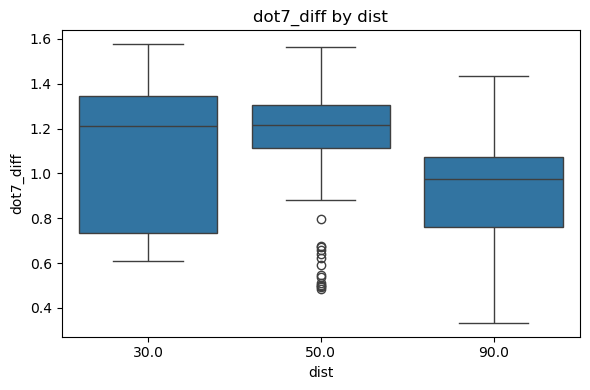

In [25]:
order = sorted(df["dist"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="dot7_diff", order=order)
plt.xlabel("dist")
plt.ylabel("dot7_diff")
plt.title("dot7_diff by dist")
plt.tight_layout()
plt.show()

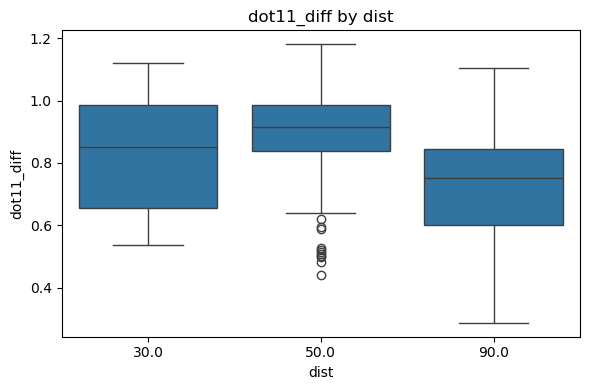

In [26]:
order = sorted(df["dist"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="dot11_diff", order=order)
plt.xlabel("dist")
plt.ylabel("dot11_diff")
plt.title("dot11_diff by dist")
plt.tight_layout()
plt.show()

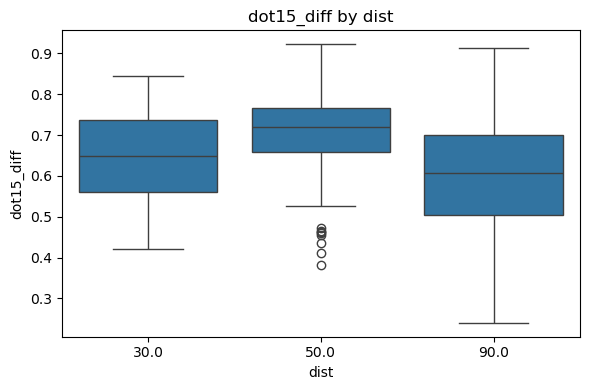

In [27]:
order = sorted(df["dist"].unique())

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="dot15_diff", order=order)
plt.xlabel("dist")
plt.ylabel("dot15_diff")
plt.title("dot15_diff by dist")
plt.tight_layout()
plt.show()

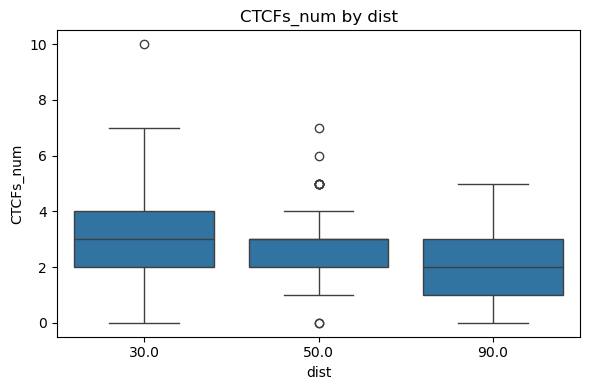

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="CTCFs_num", order=order)
plt.xlabel("dist")
plt.ylabel("CTCFs_num")
plt.title("CTCFs_num by dist")
plt.tight_layout()
plt.show()

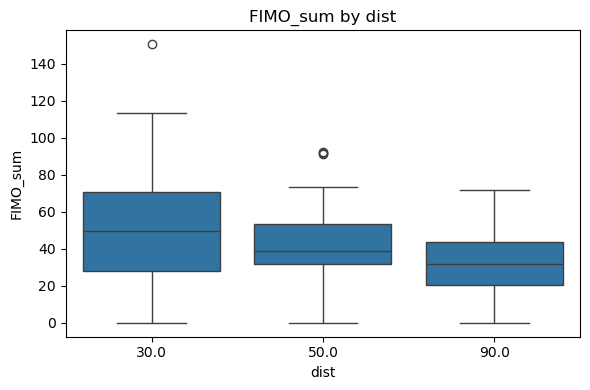

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="FIMO_sum", order=order)
plt.xlabel("dist")
plt.ylabel("FIMO_sum")
plt.title("FIMO_sum by dist")
plt.tight_layout()
plt.show()

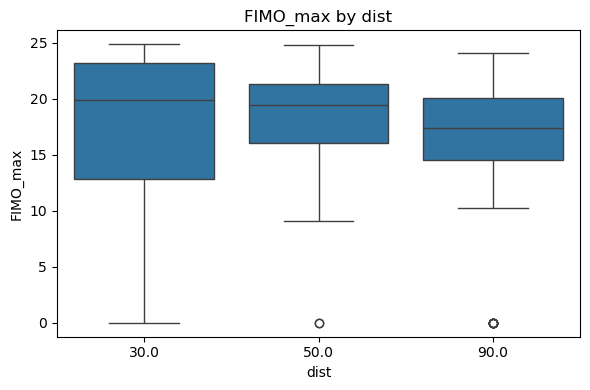

In [30]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="dist", y="FIMO_max", order=order)
plt.xlabel("dist")
plt.ylabel("FIMO_max")
plt.title("FIMO_max by dist")
plt.tight_layout()
plt.show()

### Orientation

In [31]:
def combine_orientation(row):
    o0, o1 = row["orientation_slice0"], row["orientation_slice1"]
    if o0 == "no" and o1 == "no":
        return "no"
    parts = [o for o in [o0, o1] if o != "no"]
    return "".join(parts)


In [32]:
df["orientation"] = df.apply(combine_orientation, axis=1)

In [33]:
def canonicalize(ori):
    # Flip strand = replace + <-> -
    flipped = ori.replace("+", "x").replace("-", "+").replace("x", "-")
    # Pick lexicographically smaller string as canonical
    return min(ori, flipped)

In [34]:
df["orientation_canonical"] = df["orientation"].apply(canonicalize)

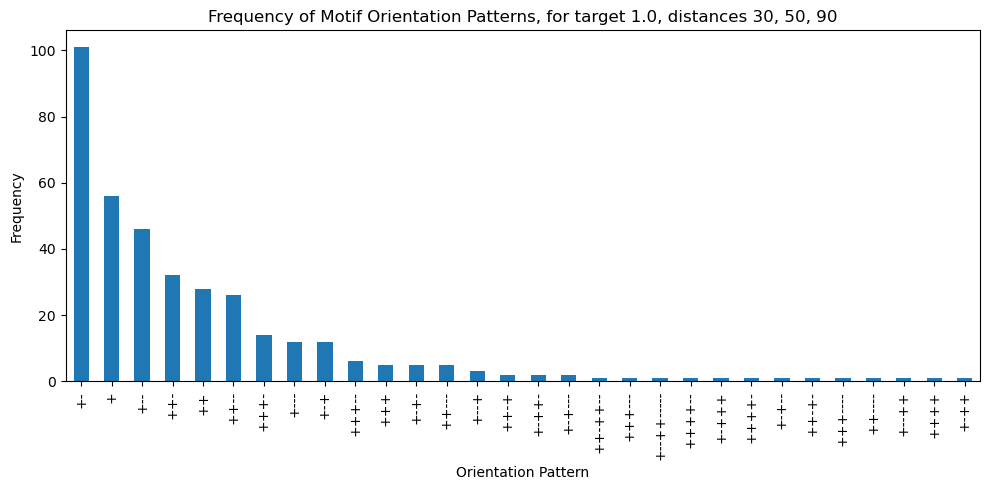

In [35]:
orientation_counts = df[df['orientation'] != "no"]['orientation_canonical'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for target 1.0, distances 30, 50, 90")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()